# **Credit-Card-Analysis**

## Objectives

* Load the cleaned BankChurners datset and test four hypotheses about customer churn using matplotlib, seborn and plotly chart per hypothesis

## Inputs

* Data_Set/Processed_Data/BankChurners_cleaned.csv 

## Outputs

* A set of visualisations and statistical test results supporting or challenging each of the four hypotheses. 

## Additional Comments

* Four hypotheses are tested in this notebook, corresponding to Section 1 through Section 4 below. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [15]:
import os
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/Project One/Credit-Cards-Analysis'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [16]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [17]:
current_dir = os.getcwd()
current_dir

'/Users/apple/Desktop/Project One'

# Libraries Import

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load Clean Data Set

This notebook loads the cleaned dataset produced by `ETL.ipynb`, rather than the raw CSV, since 
data cleaning and feature engineering (including the amount-count mismatch ratio needed for 
Hypothesis 2) were already completed there


In [19]:
df_clean = pd.read_csv('Data_Set/Processed_Data/BankChurners_cleaned.csv')
df_clean.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Data_Set/Processed_Data/BankChurners_cleaned.csv'

# Section 1

# Hypothesis 1 - Bust-Out Utilization Pattern

Customers who churn while holding a high utilization ratio and a high revolving balance, 
particularly with a short tenure, show a pattern consistent with credit "bust-out" behaviour: 
building credit quickly, maxing it out, then exiting.

### Boxplot Of Utilization Ration By Attrition Status (Matplotlib)

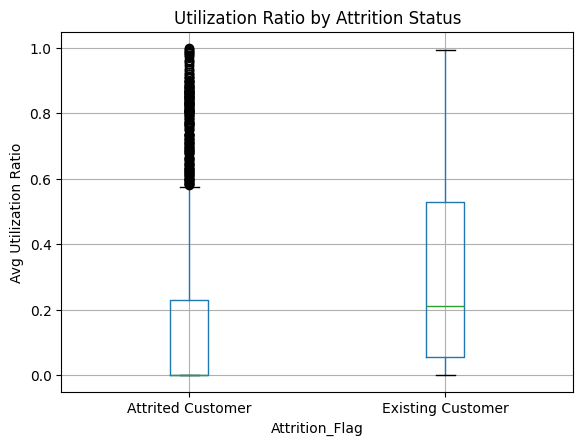

In [ ]:
df_clean.boxplot(column='Avg_Utilization_Ratio', by='Attrition_Flag')
plt.title('Utilization Ratio by Attrition Status')
plt.suptitle('')
plt.ylabel('Avg Utilization Ratio')
plt.show()

Attrited customers show a low median utilization ratio, but with a distinct 
cluster of high-utilization outliers (roughly 0.6-1.0) not seen to the same extent among existing 
customers. This suggests a subgroup of churned customers may fit a bust-out-like pattern, though the 
group as a whole does not.

### Scatter Plot Of Tenure vs Utilization Ration By Attrition Status (Seaborn)

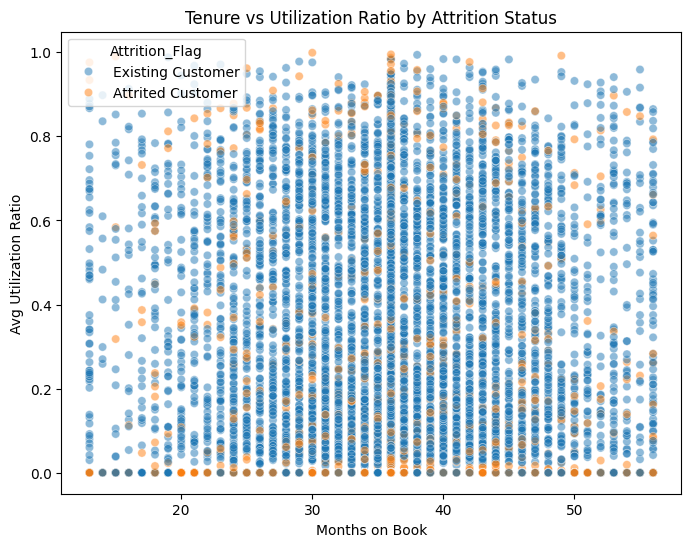

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='Months_on_book', y='Avg_Utilization_Ratio', hue='Attrition_Flag', alpha=0.5)
plt.title('Tenure vs Utilization Ratio by Attrition Status')
plt.xlabel('Months on Book')
plt.ylabel('Avg Utilization Ratio')
plt.show()

No clear clustering of attrited customers appears in the 
low-tenure/high-utilization region specifically. Points from both groups are spread similarly across 
the full range of tenure, suggesting tenure alone does not strongly separate the two groups here.

### Interactive - Tenure vs Utilization Ration By Attrition Status (Plotly)

In [ ]:
fig = px.scatter(df_clean, x='Months_on_book', y='Avg_Utilization_Ratio', color='Attrition_Flag',
                  title='Tenure vs Utilization Ratio by Attrition Status')
fig.show()

This hypothesis is only partially supported. A bust-out-like pattern appears to 
describe a minority of churned customers, rather than the churned group as a whole.

# Hypothesis 2: Spend/Frequency Mismatch

Accounts with a large mismatch between the change in transaction amount and the change in 
transaction count are disproportionately represented among attrited accounts.

### Histogram Of Amount-Count Mismatch Ratio (Matplotlib)

In [ ]:
print(f"Infinite values found: {np.isinf(df_clean['Amt_Count_Mismatch_Ratio']).sum()} out of {len(df_clean)}")

Infinite values found: 2 out of 10127


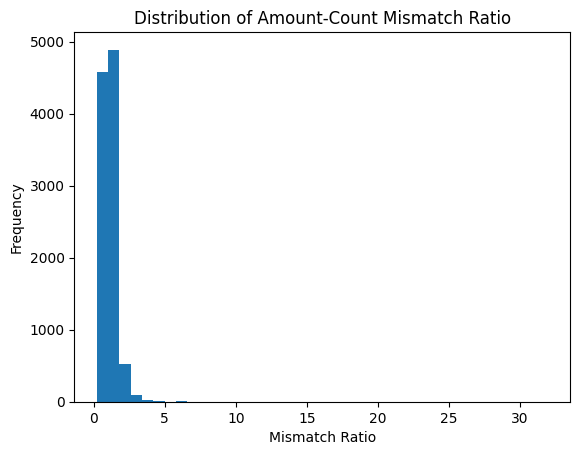

In [ ]:
finite_mismatch = df_clean['Amt_Count_Mismatch_Ratio'].replace([np.inf, -np.inf], np.nan).dropna()

finite_mismatch.plot(kind='hist', bins=40)
plt.title('Distribution of Amount-Count Mismatch Ratio')
plt.xlabel('Mismatch Ratio')
plt.ylabel('Frequency')
plt.show()

The distribution is heavily right-skewed. The large majority of customers 
have a mismatch ratio between 0 and 2, with a long thin tail of outliers extending out beyond 30. 
Two infinite values (caused by a small number of customers with zero transaction count change) were 
excluded before plotting.

### Boxplot Of Mismatch Ratio By Attrition Status (Seaborn)

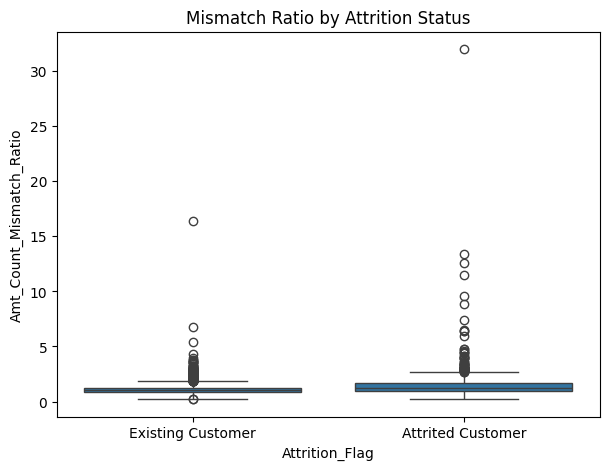

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Attrition_Flag', y='Amt_Count_Mismatch_Ratio')
plt.title('Mismatch Ratio by Attrition Status')
plt.show()

Both groups show a median mismatch ratio close to 0, but attrited customers 
show a denser cluster of higher outliers (roughly 5-15), plus one extreme outlier near 30, compared 
to existing customers' more limited spread of outliers. This offers some support for the hypothesis, 
though the difference in medians between the two groups is minimal.

### Interactive - Transaction Count Change vs Amount Change By Attrition Status (Plotly)

In [ ]:
fig = px.scatter(df_clean, x='Total_Ct_Chng_Q4_Q1', y='Total_Amt_Chng_Q4_Q1', color='Attrition_Flag',
                  title='Transaction Count Change vs Amount Change by Attrition Status')
fig.show()

Attrited customers cluster tightly in the low-count-change/low-amount-change 
corner, while existing customers show a much wider spread, including many customers with larger 
increases in both metrics. Rather than showing attrited customers moving off the diagonal (a 
mismatch between amount and count), this suggests attrited customers are better characterised by 
generally low transaction activity across both measures, rather than by a specific mismatch between 
them.

This hypothesis is only partially supported. The boxplot's outlier pattern offers weak 
support, but the scatter plot suggests general low activity - not a specific amount/count mismatch - 
better explains the churned group's transaction behaviour.

# Hypothesis 3: Limit-Maxing Before Exit

Churned customers carry a higher utilization ratio than retained customers, and this gap is 
largest among customers holding fewer products with the bank.

### Bar Chart Of Mean Utilization Ratio By Attrition Status (Matplotlib)

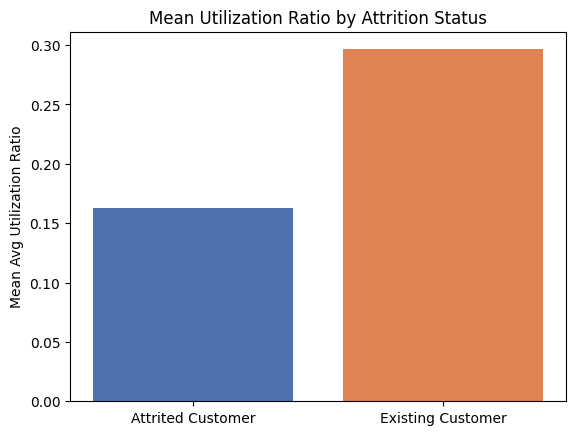

In [20]:
means = df_clean.groupby('Attrition_Flag')['Avg_Utilization_Ratio'].mean()
plt.bar(means.index, means.values, color=['#4C72B0', '#DD8452'])
plt.title('Mean Utilization Ratio by Attrition Status')
plt.ylabel('Mean Avg Utilization Ratio')
plt.show()

Contrary to the hypothesis, existing customers show a notably higher mean 
utilization ratio (~0.30) than attrited customers (~0.16) - the opposite of the predicted direction.

### Boxplot Of Utilization Ratio By Attrition Status And Relationship Count (Seaborn)

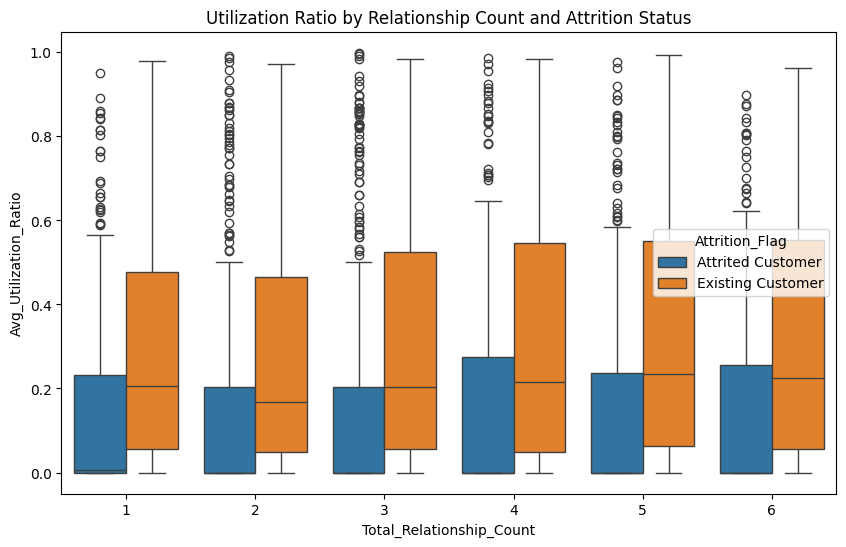

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Total_Relationship_Count', y='Avg_Utilization_Ratio', hue='Attrition_Flag')
plt.title('Utilization Ratio by Relationship Count and Attrition Status')
plt.show()

This reversal holds consistently across every relationship count level (1 
through 6): existing customers show a higher median and a higher upper quartile than attrited 
customers in every single group, not just on average overall.

### Interactive Heatmap - Utilization Ratio By Relationship Count And Attrition Status (Plotly)

In [22]:
pivot = df_clean.pivot_table(values='Avg_Utilization_Ratio', index='Total_Relationship_Count',
                              columns='Attrition_Flag', aggfunc='mean')

fig = px.imshow(pivot, text_auto='.2f', aspect='auto',
                 title='Mean Utilization Ratio: Relationship Count vs Attrition Status')
fig.show()

The gap between existing and attrited customers stays roughly constant across 
all relationship counts (approximately 0.11-0.14 at every level), rather than shrinking as 
relationship count increases. This means the second part of the hypothesis - that the gap would be 
largest among low-relationship-count customers - is not supported either; there is no clear 
moderating effect from relationship count.

This hypothesis is not supported. The data shows the opposite pattern to what was 
predicted: existing (retained) customers carry a higher utilization ratio than attrited customers, 
and this holds consistently regardless of how many products a customer holds. A plausible 
explanation is that customers who are about to churn may be paying down and reducing their card 
usage before closing the account, rather than maxing it out - the reverse of a "bust-out" pattern.

---

# Section 2

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Conclusions and Next Steps

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
